# Airline Delay Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [3]:
df_raw = pd.read_csv('airline_delay_data.csv')
print(f'Shape : {df_raw.shape}')
print()
df_raw.head(25)

Shape : (1530, 25)



,flight_id,flight_number,date,month,day_of_week,is_weekend,airline,aircraft_type,origin,destination,...,load_factor_pct,weather_origin,weather_dest,origin_congestion,dest_congestion,atc_delay_min,late_aircraft_min,tech_issue_delay_min,dep_delay_min,arr_delay_min
0,FL0430,I5797,2023-06-07,6,Wednesday,0,AirAsia India,A319,JAI,BHO,...,80.0,9.0,10.0,4,2,0.0,0.0,0.0,31.0,77.4
1,FL0330,6E841,2023-01-17,1,Tuesday,0,IndiGo,A320,PAT,BOM,...,87.2,9.0,8.0,2,9,4.1,22.9,0.0,59.6,111.7
2,FL0061,6E101,2023-03-22,3,Wednesday,0,IndiGo,B737,PAT,VTZ,...,83.8,1.0,6.0,2,2,17.3,0.0,0.0,16.0,44.9
3,FL0848,UK956,2023-11-22,11,Wednesday,0,Vistara,A320,CCU,BLR,...,73.1,1.0,4.0,5,7,6.9,0.0,0.0,6.5,32.3
4,FL1448,6E811,2023-05-23,5,Tuesday,0,IndiGo,B737,ATQ,BHO,...,71.9,5.0,7.0,2,2,NaN,27.0,0.0,42.1,55.8
5,FL0726,SG818,2023-08-12,8,Saturday,1,SpiceJet,CRJ-900,JAI,BOM,...,89.9,7.0,6.0,4,9,3.1,10.9,0.0,40.5,116.9
6,FL1163,SG901,2023-07-01,7,Saturday,1,SpiceJet,B737,BHO,ATQ,...,78.1,6.0,7.0,2,2,10.7,0.0,0.0,23.3,77.8
7,FL0596,6E638,2023-08-09,8,Wednesday,0,IndiGo,B737,IXB,GAU,...,71.8,4.0,8.0,2,2,1.4,29.4,0.0,41.4,82.1
8,FL0222,G8505,2023-11-20,11,Monday,0,GoFirst,A320,PNQ,ATQ,...,76.8,6.0,5.0,4,2,2.6,0.0,0.0,9.4,29.1
9,FL0479,6E681,2023-10-16,10,Monday,0,IndiGo,A321,DEL,VTZ,...,81.1,6.0,2.0,9,2,19.5,0.0,0.0,40.9,25.9


In [4]:
print('Column names and types:')
print(df_raw.dtypes)

Column names and types:
flight_id                   str
flight_number               str
date                        str
month                     int64
day_of_week                 str
is_weekend                int64
airline                     str
aircraft_type               str
origin                      str
destination                 str
distance_km               int64
scheduled_dep_hour        int64
flight_duration_min       int64
seat_capacity             int64
passengers_boarded      float64
load_factor_pct         float64
weather_origin          float64
weather_dest            float64
origin_congestion         int64
dest_congestion           int64
atc_delay_min           float64
late_aircraft_min       float64
tech_issue_delay_min    float64
dep_delay_min           float64
arr_delay_min           float64
dtype: object


In [5]:
# Missing values
missing = df_raw.isnull().sum()
miss_df = pd.DataFrame({'Missing Count': missing})
miss_df = miss_df[miss_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(f'\n1. Missing values found in {len(miss_df)} columns:')
print(miss_df.to_string())

# Duplicates
dupes = df_raw.duplicated().sum()
print(f'\n2. Duplicate rows : {dupes}')


1. Missing values found in 7 columns:
                    Missing Count
atc_delay_min                  91
load_factor_pct                90
late_aircraft_min              90
weather_origin                 76
weather_dest                   75
passengers_boarded             60
aircraft_type                  46

2. Duplicate rows : 30


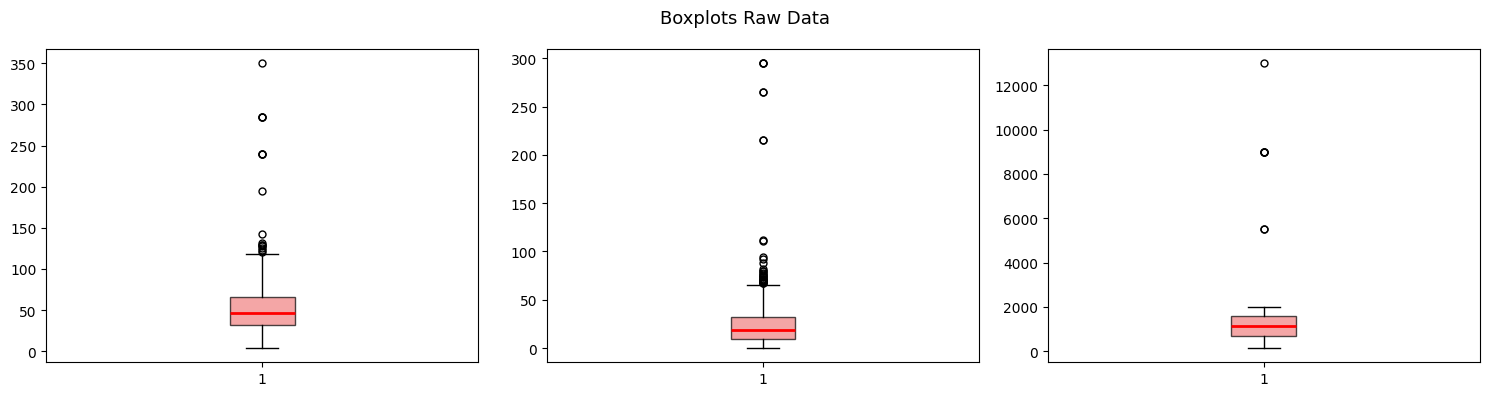

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['arr_delay_min','dep_delay_min','distance_km']):
    data = df_raw[col].dropna()
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor='lightcoral', alpha=0.7),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markersize=5))

plt.suptitle('Boxplots Raw Data', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
df = df_raw.copy()
before = len(df)
df = df.drop_duplicates()
after  = len(df)
print(f'Rows before : {before}')
print(f'Rows after  : {after}')
print(f'Removed     : {before - after}')

Rows before : 1530
Rows after  : 1500
Removed     : 30


In [8]:
print('Missing values BEFORE filling:')
mv = df.isnull().sum()
print(mv[mv > 0].to_string())
print()

# MEAN imputation

mean_cols = {
    'weather_origin',
    'weather_dest',
    'load_factor_pct',
    'atc_delay_min',
    'late_aircraft_min',
    'passengers_boarded',
}

for col in mean_cols:
    n_null   = df[col].isnull().sum()
    col_mean = df[col].mean()
    df[col]  = df[col].fillna(col_mean)
    print(f'  [MEAN]  {col:<22}  {n_null:>3} nulls filled with mean = {col_mean:.2f}')

print()

# MODE imputation

col      = 'aircraft_type'
n_null   = df[col].isnull().sum()
col_mode = df[col].mode()[0]
df[col]  = df[col].fillna(col_mode)
print(f'  [MODE]  {col:<22}  {n_null:>3} nulls filled with mode = {col_mode}')

print()
print(f'Total missing values after filling : {df.isnull().sum().sum()}')
print()


Missing values BEFORE filling:
aircraft_type         45
passengers_boarded    60
load_factor_pct       90
weather_origin        75
weather_dest          75
atc_delay_min         90
late_aircraft_min     90

  [MEAN]  atc_delay_min            90 nulls filled with mean = 5.18
  [MEAN]  late_aircraft_min        90 nulls filled with mean = 4.01
  [MEAN]  load_factor_pct          90 nulls filled with mean = 82.26
  [MEAN]  passengers_boarded       60 nulls filled with mean = 149.95
  [MEAN]  weather_dest             75 nulls filled with mean = 4.59
  [MEAN]  weather_origin           75 nulls filled with mean = 4.62

  [MODE]  aircraft_type            45 nulls filled with mode = A320

Total missing values after filling : 0



In [9]:
before = len(df)

# Remove outliers from key numeric columns
for col in ['arr_delay_min', 'dep_delay_min', 'distance_km']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    removed = df[(df[col] < lo) | (df[col] > hi)].shape[0]
    df = df[(df[col] >= lo) & (df[col] <= hi)]
    print(f'{col:<22}: {removed} outliers')

df = df.reset_index(drop=True)
print(f'\nRows before outlier removal : {before}')
print(f'Rows after  outlier removal : {len(df)}')
print(f'Total removed               : {before - len(df)}')

arr_delay_min         : 17 outliers
dep_delay_min         : 33 outliers
distance_km           : 7 outliers

Rows before outlier removal : 1500
Rows after  outlier removal : 1443
Total removed               : 57


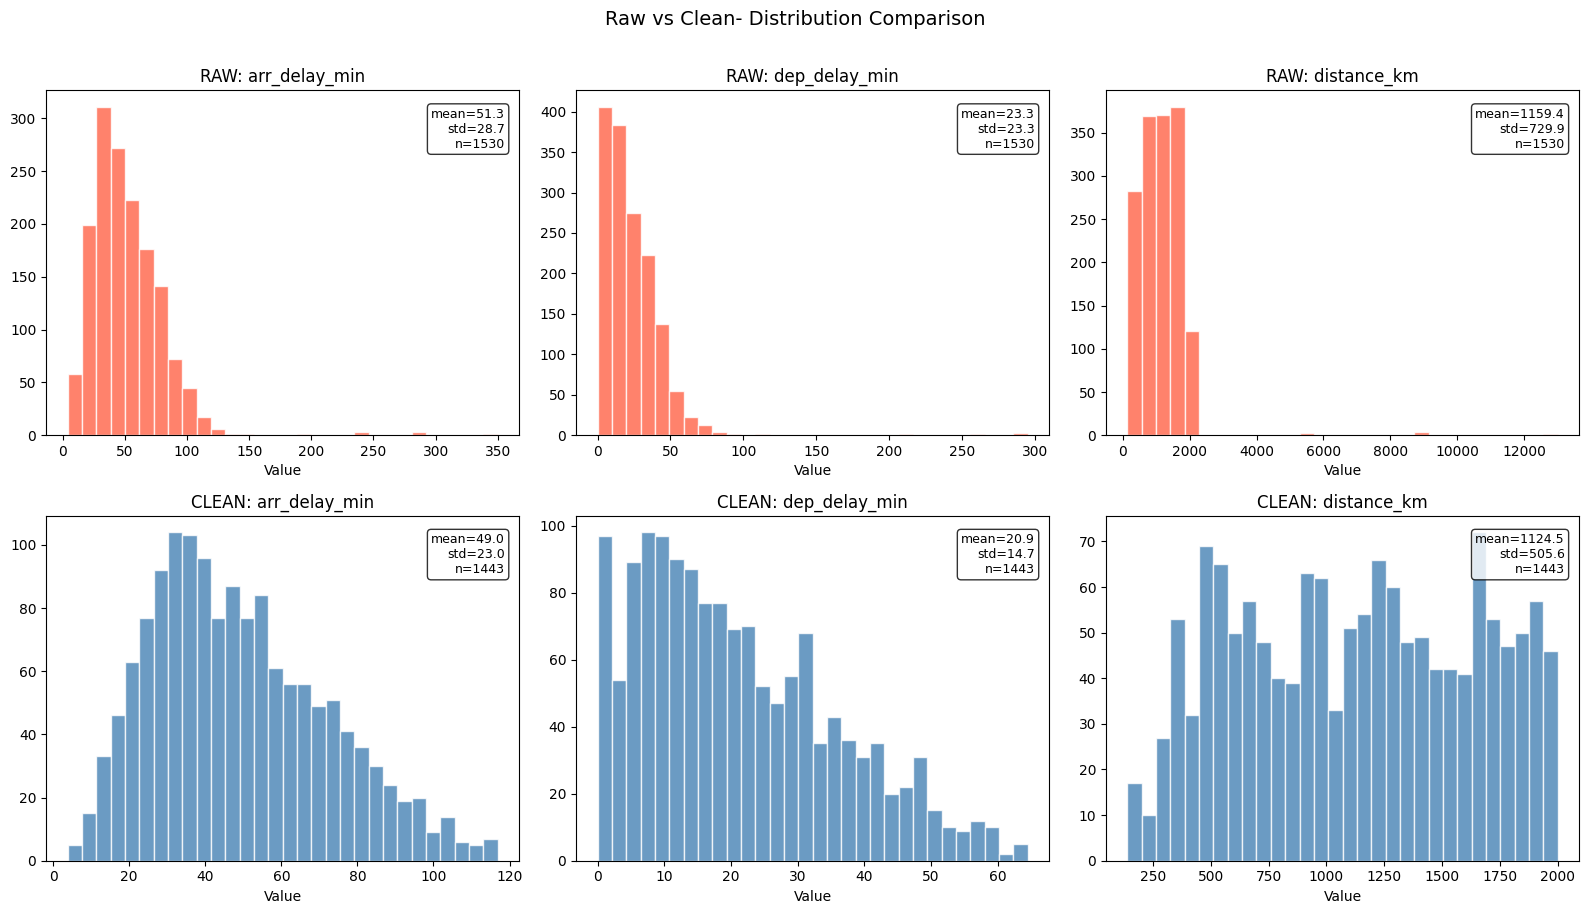

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

compare_cols = ['arr_delay_min', 'dep_delay_min', 'distance_km']

for col, ax_raw, ax_clean in zip(compare_cols, axes[0], axes[1]):
    raw_data   = df_raw[col].dropna()
    clean_data = df[col]

    ax_raw.hist(raw_data,   bins=30, color='tomato',      edgecolor='white', alpha=0.8)
    ax_raw.set_title(f'RAW: {col}')
    ax_raw.set_xlabel('Value')
    ax_raw.text(0.97, 0.95, f'mean={raw_data.mean():.1f}\nstd={raw_data.std():.1f}\nn={len(raw_data)}',
                transform=ax_raw.transAxes, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

    ax_clean.hist(clean_data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax_clean.set_title(f'CLEAN: {col}')
    ax_clean.set_xlabel('Value')
    ax_clean.text(0.97, 0.95, f'mean={clean_data.mean():.1f}\nstd={clean_data.std():.1f}\nn={len(clean_data)}',
                  transform=ax_clean.transAxes, ha='right', va='top',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

plt.suptitle('Raw vs Clean- Distribution Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# Summary table: before vs after
print(f'  {"":30} {"RAW":>12}   {"CLEAN":>12}')
print(f'  {"Total rows":<30} {len(df_raw):>12}   {len(df):>12}')
print(f'  {"Missing values":<30} {int(df_raw.isnull().sum().sum()):>12}   {int(df.isnull().sum().sum()):>12}')
print(f'  {"Duplicate rows":<30} {int(df_raw.duplicated().sum()):>12}   {int(df.duplicated().sum()):>12}')
print(f'  {"arr_delay max (min)":<30} {df_raw["arr_delay_min"].max():>12.0f}   {df["arr_delay_min"].max():>12.1f}')
print(f'  {"arr_delay mean (min)":<30} {df_raw["arr_delay_min"].mean():>12.1f}   {df["arr_delay_min"].mean():>12.1f}')
print(f'  {"arr_delay std (min)":<30} {df_raw["arr_delay_min"].std():>12.1f}   {df["arr_delay_min"].std():>12.1f}')
print(f'  {"distance_km max":<30} {df_raw["distance_km"].max():>12.0f}   {df["distance_km"].max():>12.0f}')

                                          RAW          CLEAN
  Total rows                             1530           1443
  Missing values                          528              0
  Duplicate rows                           30              0
  arr_delay max (min)                     350          116.9
  arr_delay mean (min)                   51.3           49.0
  arr_delay std (min)                    28.7           23.0
  distance_km max                       13000           2000


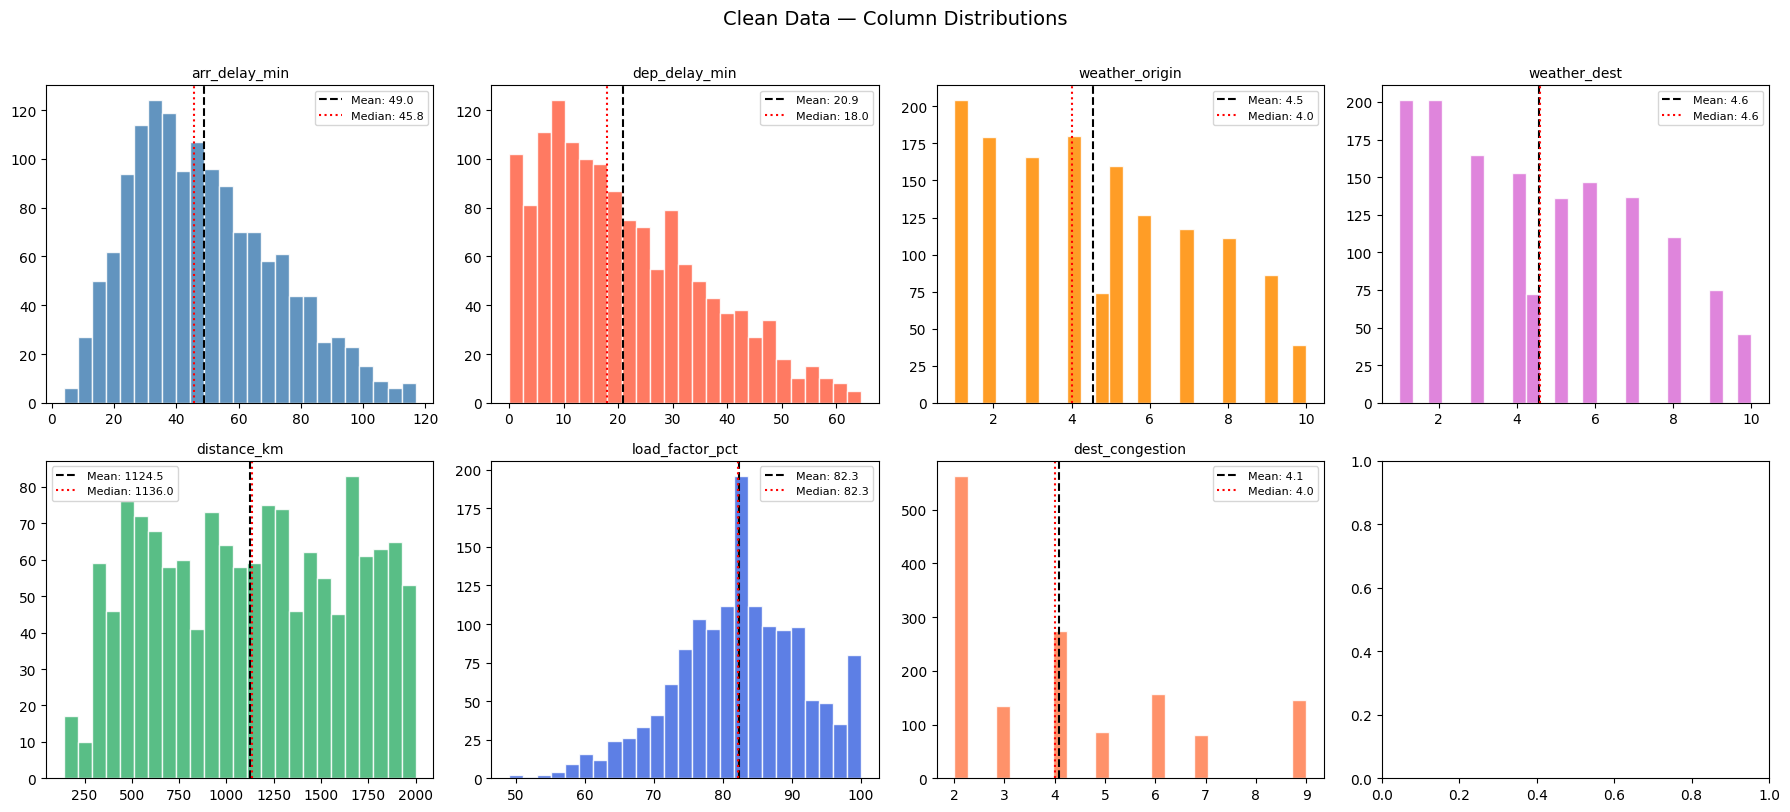

In [12]:
num_cols = ['arr_delay_min','dep_delay_min','weather_origin','weather_dest',
            'distance_km','load_factor_pct','dest_congestion']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
colors = ['steelblue','tomato','darkorange','orchid','mediumseagreen','royalblue','coral','gold']

for ax, col, color in zip(axes.flat, num_cols, colors):
    ax.hist(df[col], bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='black',  linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='red', linestyle=':',  linewidth=1.5,
               label=f'Median: {df[col].median():.1f}')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Clean Data — Column Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

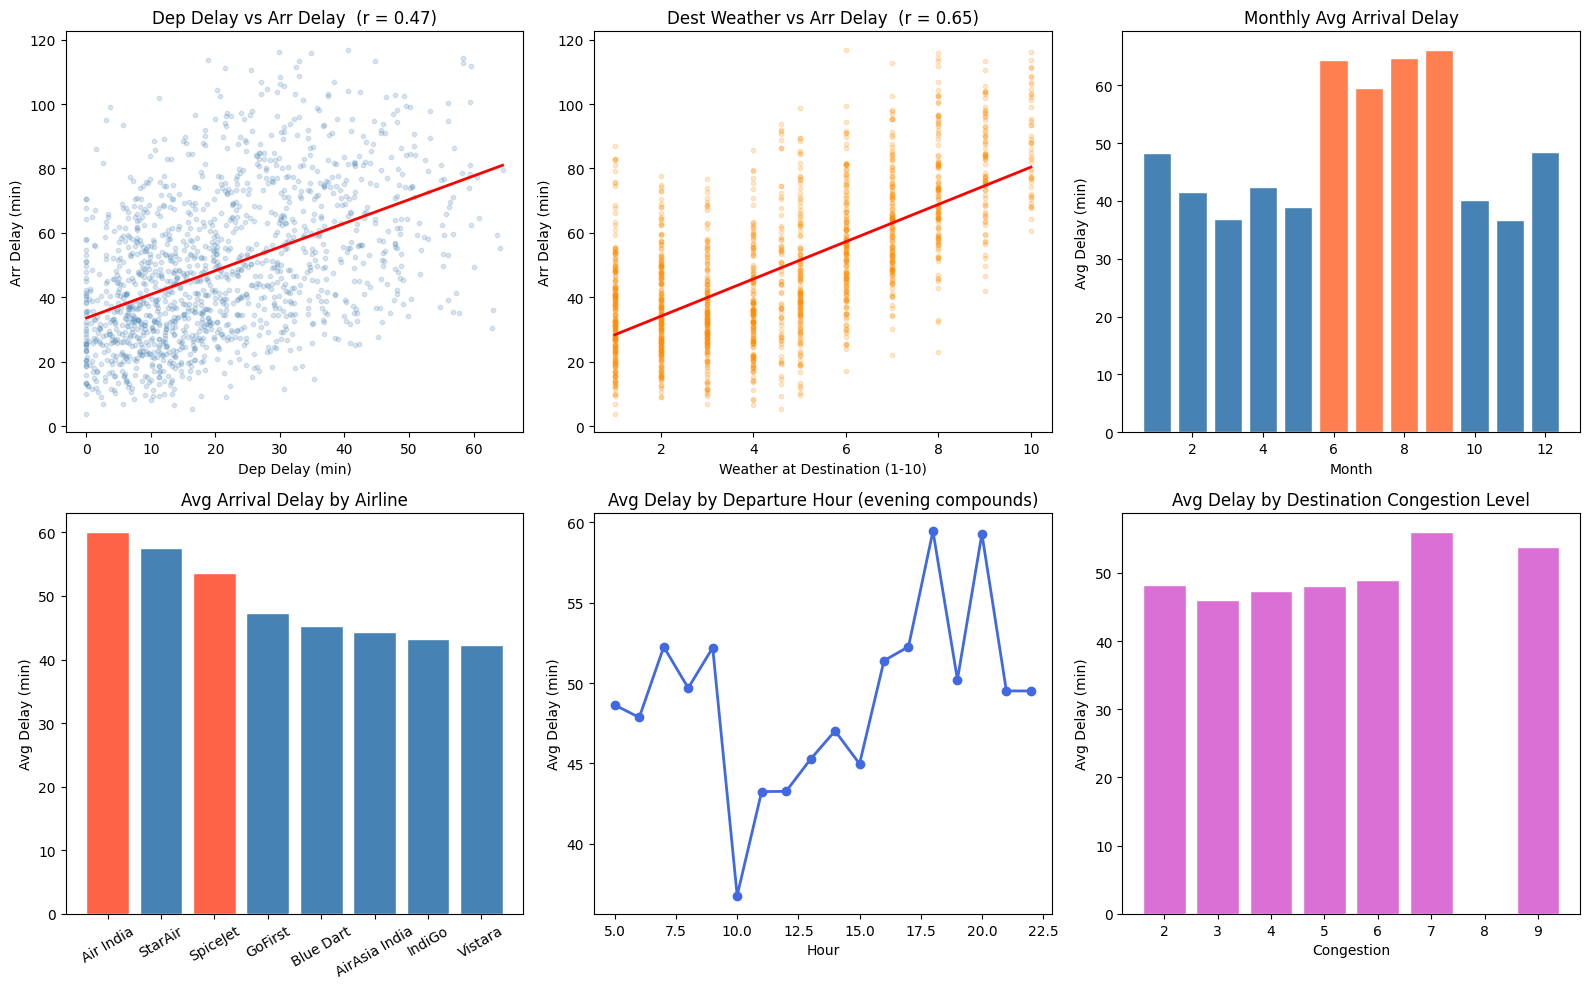

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Dep delay vs Arr delay
axes[0,0].scatter(df['dep_delay_min'], df['arr_delay_min'], alpha=0.2, s=10, color='steelblue')
z = np.polyfit(df['dep_delay_min'], df['arr_delay_min'], 1)
xl = np.linspace(0, df['dep_delay_min'].max(), 100)
axes[0,0].plot(xl, np.poly1d(z)(xl), 'r-', linewidth=2)
r = df['dep_delay_min'].corr(df['arr_delay_min'])
axes[0,0].set_title(f'Dep Delay vs Arr Delay  (r = {r:.2f})')
axes[0,0].set_xlabel('Dep Delay (min)'); axes[0,0].set_ylabel('Arr Delay (min)')

# 2. Weather at dest vs Arr delay
axes[0,1].scatter(df['weather_dest'], df['arr_delay_min'], alpha=0.2, s=10, color='darkorange')
z2 = np.polyfit(df['weather_dest'], df['arr_delay_min'], 1)
xl2 = np.linspace(1, 10, 100)
axes[0,1].plot(xl2, np.poly1d(z2)(xl2), 'r-', linewidth=2)
r2 = df['weather_dest'].corr(df['arr_delay_min'])
axes[0,1].set_title(f'Dest Weather vs Arr Delay  (r = {r2:.2f})')
axes[0,1].set_xlabel('Weather at Destination (1-10)'); axes[0,1].set_ylabel('Arr Delay (min)')

# 3. Monthly avg delay
monthly = df.groupby('month')['arr_delay_min'].mean()
mn = ['J','F','M','A','M','J','J','A','S','O','N','D']
bar_colors = ['coral' if m in [6,7,8,9] else 'steelblue' for m in range(1,13)]
axes[0,2].bar(range(1,13), monthly.values, color=bar_colors, edgecolor='white')
axes[0,2].set_title('Monthly Avg Arrival Delay')
axes[0,2].set_xlabel('Month'); axes[0,2].set_ylabel('Avg Delay (min)')

# 4. Airline comparison
al_avg = df.groupby('airline')['arr_delay_min'].mean().sort_values(ascending=False)
bar_c2 = ['tomato' if a in ['Air India','SpiceJet'] else 'steelblue' for a in al_avg.index]
axes[1,0].bar(al_avg.index, al_avg.values, color=bar_c2, edgecolor='white')
axes[1,0].set_title('Avg Arrival Delay by Airline')
axes[1,0].set_ylabel('Avg Delay (min)')
axes[1,0].tick_params(axis='x', rotation=30)

# 5. Hour of day
hourly = df.groupby('scheduled_dep_hour')['arr_delay_min'].mean()
axes[1,1].plot(hourly.index, hourly.values, marker='o', color='royalblue', linewidth=2)
axes[1,1].set_title('Avg Delay by Departure Hour (evening compounds)')
axes[1,1].set_xlabel('Hour'); axes[1,1].set_ylabel('Avg Delay (min)')

# 6. Dest congestion vs delay
cong = df.groupby('dest_congestion')['arr_delay_min'].mean()
axes[1,2].bar(cong.index, cong.values, color='orchid', edgecolor='white')
axes[1,2].set_title('Avg Delay by Destination Congestion Level')
axes[1,2].set_xlabel('Congestion'); 
axes[1,2].set_ylabel('Avg Delay (min)')

plt.tight_layout()
plt.show()

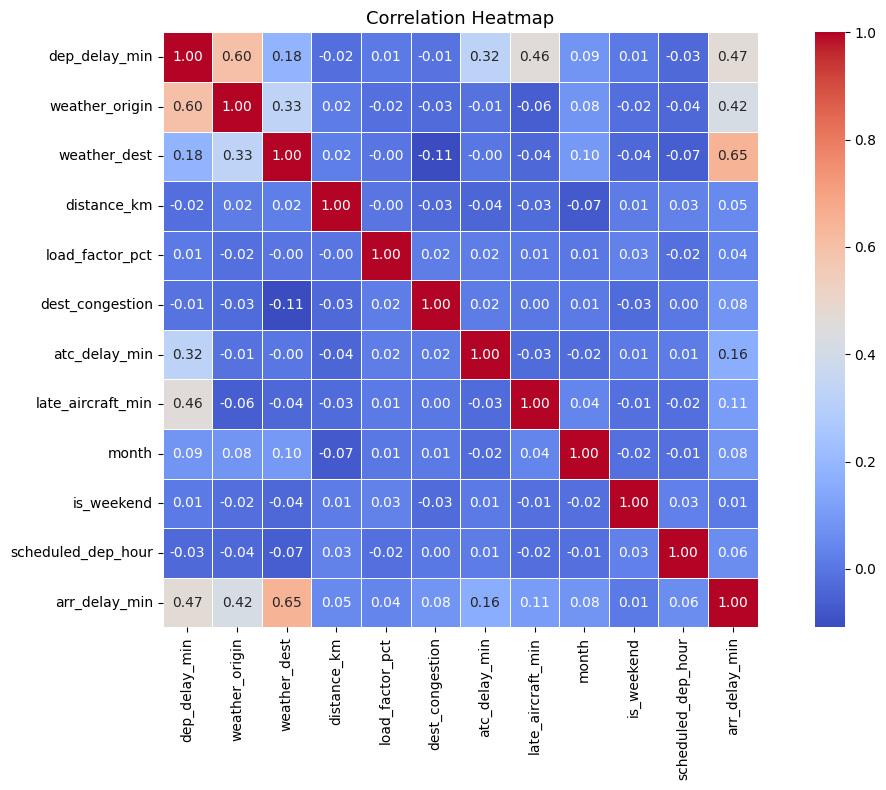

In [14]:
# Correlation heatmap
features = ['dep_delay_min','weather_origin','weather_dest','distance_km',
            'load_factor_pct','dest_congestion','atc_delay_min',
            'late_aircraft_min','month','is_weekend','scheduled_dep_hour']

plt.figure(figsize=(12, 8))
corr_matrix = df[features + ['arr_delay_min']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
print('Feature ranges BEFORE normalisation:')
print(f'  {"Feature":<25} {"Min":>10}  {"Max":>10}  {"Range":>10}')
for f in features:
    mn_v = df[f].min(); mx_v = df[f].max()
    print(f'  {f:<25} {mn_v:>10.1f}  {mx_v:>10.1f}  {mx_v-mn_v:>10.1f}')

Feature ranges BEFORE normalisation:
  Feature                          Min         Max       Range
  dep_delay_min                    0.0        64.5        64.5
  weather_origin                   1.0        10.0         9.0
  weather_dest                     1.0        10.0         9.0
  distance_km                    140.0      2000.0      1860.0
  load_factor_pct                 49.0       100.0        51.0
  dest_congestion                  2.0         9.0         7.0
  atc_delay_min                    0.0        37.3        37.3
  late_aircraft_min                0.0        46.5        46.5
  month                            1.0        12.0        11.0
  is_weekend                       0.0         1.0         1.0
  scheduled_dep_hour               5.0        22.0        17.0


In [16]:
# Apply Min-Max normalisation
X_raw_vals = df[features].copy().reset_index(drop=True)
y          = df['arr_delay_min'].copy().reset_index(drop=True)

scaler   = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw_vals), columns=features)

print('Feature ranges AFTER Min-Max normalisation:')
print(f'  {"Feature":<25} {"Min":>8}  {"Max":>8}')
for f in features:
    print(f'  {f:<25} {X_scaled[f].min():>8.3f}  {X_scaled[f].max():>8.3f}')

Feature ranges AFTER Min-Max normalisation:
  Feature                        Min       Max
  dep_delay_min                0.000     1.000
  weather_origin               0.000     1.000
  weather_dest                 0.000     1.000
  distance_km                  0.000     1.000
  load_factor_pct              0.000     1.000
  dest_congestion              0.000     1.000
  atc_delay_min                0.000     1.000
  late_aircraft_min            0.000     1.000
  month                        0.000     1.000
  is_weekend                   0.000     1.000
  scheduled_dep_hour           0.000     1.000


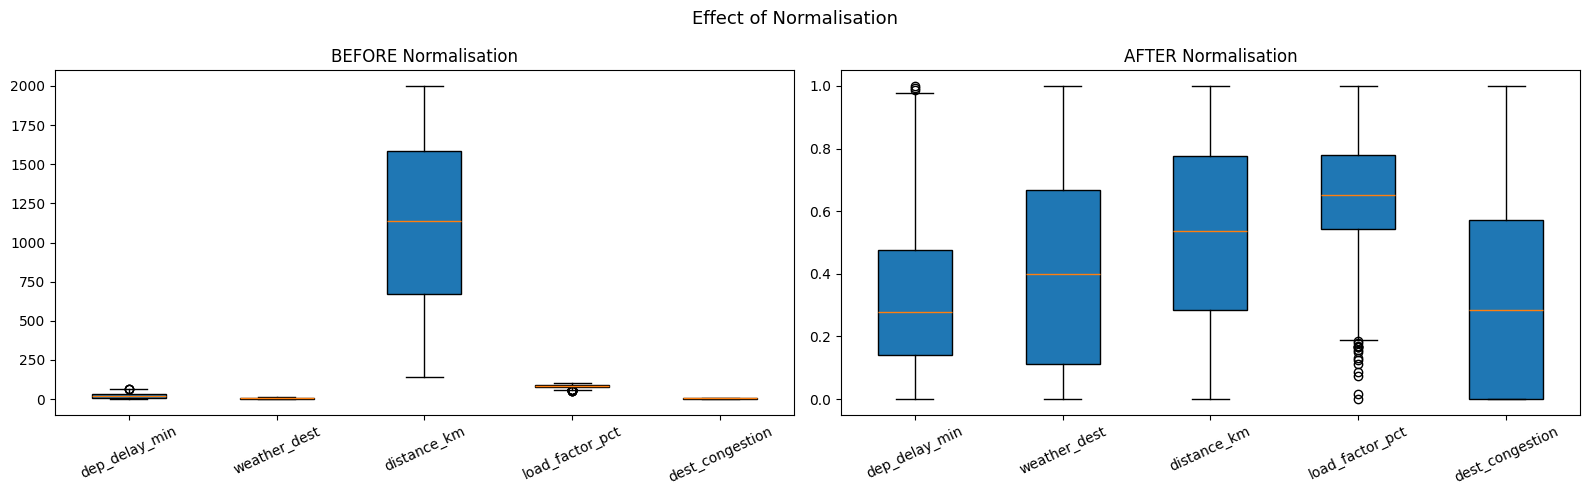

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

show = ['dep_delay_min','weather_dest','distance_km','load_factor_pct','dest_congestion']

axes[0].boxplot([X_raw_vals[c].values for c in show],
                tick_labels=show, patch_artist=True)
axes[0].set_title('BEFORE Normalisation')
axes[0].tick_params(axis='x', rotation=25)

axes[1].boxplot([X_scaled[c].values for c in show],
                tick_labels=show, patch_artist=True)
axes[1].set_title('AFTER Normalisation')
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle('Effect of Normalisation', fontsize=13)
plt.tight_layout()
plt.show()